In [60]:
import pandas as pd

# Ladda in CSV dataset
# netflix = pd.read_csv("netflix Dataset.csv")
df = pd.read_csv("TMDB_all_movies.csv")

df.head()

print(df.dtypes)

id                           int64
title                       object
vote_average               float64
vote_count                 float64
status                      object
release_date                object
revenue                    float64
runtime                    float64
budget                     float64
imdb_id                     object
original_language           object
original_title              object
overview                    object
popularity                 float64
tagline                     object
genres                      object
production_companies        object
production_countries        object
spoken_languages            object
cast                        object
director                    object
director_of_photography     object
writers                     object
producers                   object
music_composer              object
imdb_rating                float64
imdb_votes                 float64
poster_path                 object
dtype: object


In [6]:
netflix['Release_Year'] = pd.to_datetime(netflix['Release_Date'], errors='coerce').dt.year
netflix['Release_Year'] = netflix['Release_Year'].fillna(0).astype(int)
def parse_duration(x):
    if pd.isna(x):
        return 0
    if "Season" in x:   # TV Show
        return int(x.split()[0])   # antal säsonger
    if "min" in x:      # Movie
        return int(x.split()[0])   # antal minuter
    return 0

netflix['Duration_num'] = netflix['Duration'].apply(parse_duration)

print(netflix[['Title', 'Duration', 'Duration_num', 'Release_Date', 'Release_Year']].head(10))
print(netflix.dtypes)

   Title   Duration  Duration_num       Release_Date  Release_Year
0     3%  4 Seasons             4    August 14, 2020          2020
1  07:19     93 min            93  December 23, 2016          2016
2  23:59     78 min            78  December 20, 2018          2018
3      9     80 min            80  November 16, 2017          2017
4     21    123 min           123    January 1, 2020          2020
5     46   1 Season             1       July 1, 2017          2017
6    122     95 min            95       June 1, 2020          2020
7    187    119 min           119   November 1, 2019          2019
8    706    118 min           118      April 1, 2019          2019
9   1920    143 min           143  December 15, 2017          2017
Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
Release_Ye

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.sparse import hstack, csr_matrix
from scipy.spatial import ConvexHull

import matplotlib.pyplot as plt
# Steg 1: Läs in data
df = pd.read_csv("Netflix Dataset.csv")

# Separera filmer (minuter) och serier (säsonger)
movies = df[df['Duration'].str.contains("min", na=False)].copy()
shows = df[df['Duration'].str.contains("Season", na=False)].copy()

# Extrahera minuter/säsonger
movies['Minutes'] = movies['Duration'].str.extract(r'(\d+)').astype(float)
shows['Seasons'] = shows['Duration'].str.extract(r'(\d+)').astype(float)

# Rensa Duration-text
movies['Duration'] = movies['Duration'].str.replace(r'\d+', '', regex=True).str.strip()
shows['Duration'] = shows['Duration'].str.replace(r'\d+', '', regex=True).str.strip()

print(f"Antal filmer: {movies.shape[0]}")
print(movies[['Title', 'Duration', 'Minutes']].head())
print(f"Antal serier: {shows.shape[0]}")
print(shows[['Title', 'Duration', 'Seasons']].head())

Antal filmer: 5379
   Title Duration  Minutes
1  07:19      min     93.0
2  23:59      min     78.0
3      9      min     80.0
4     21      min    123.0
6    122      min     95.0
Antal serier: 2410
     Title Duration  Seasons
0       3%  Seasons      4.0
5       46   Season      1.0
11    1983   Season      1.0
12    1994   Season      1.0
16  Feb-09   Season      1.0


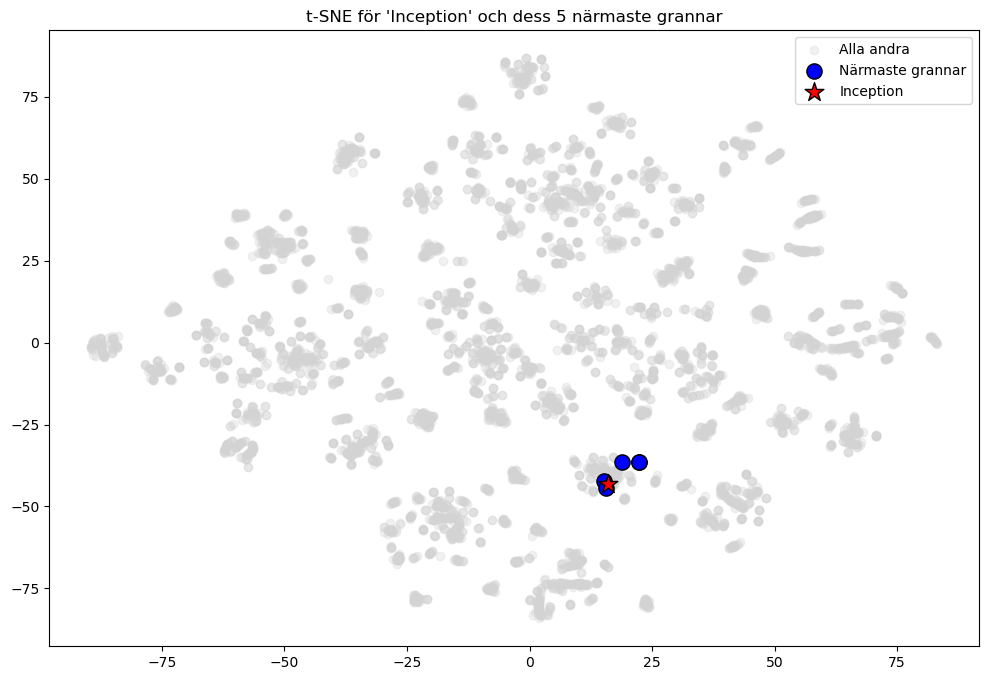


De 5 närmaste filmerna till 'Inception':
1. Across the Universe
2. Stranger than Fiction
3. Yes Man
4. Rize
5. The Lord of the Rings: The Return of the King

--- Klusterprofilering
Cluster 0:
   Vanligaste Type     = Children & Family Movies
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-PG
   Antal titlar        = 752

Cluster 1:
   Vanligaste Type     = Dramas, International Movies
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-MA
   Antal titlar        = 1174

Cluster 2:
   Vanligaste Type     = Documentaries
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-14
   Antal titlar        = 702

Cluster 3:
   Vanligaste Type     = Action & Adventure
   Vanligaste Category = Movie
   Vanligaste Rating   = R
   Antal titlar        = 998

Cluster 4:
   Vanligaste Type     = Dramas, International Movies
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-14
   Antal titlar        = 1080

Cluster 5:
   Vanligaste Type     = Stand-Up Comedy
   Vanligast

In [11]:
# Hantera saknad description
movies['Description'] = movies['Description'].fillna("")

# Extrahera år
movies['Release_Year'] = pd.to_datetime(movies['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)

# Steg 2: Generera features
# Text (Description)
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
tfidf_desc = tfidf.fit_transform(movies['Description'])

# Kategoriska features
cat_cols = ['Type', 'Category', 'Rating', 'Country']
encoder = OneHotEncoder(handle_unknown='ignore')
cat_feats = encoder.fit_transform(movies[cat_cols].fillna("Unknown"))

# Numeriska features
num_feats = movies[['Release_Year', 'Minutes']].fillna(0).values
scaler = StandardScaler()
num_feats_scaled = scaler.fit_transform(num_feats)

# Kombinera features med vikter
tfidf_w = 0.7
cat_w   = 1.2
num_w   = 0.5

X = hstack([
    tfidf_desc * tfidf_w,
    cat_feats * cat_w,
    num_feats_scaled * num_w
])

# CSR-format
X_csr = csr_matrix(X)

# Steg 3: Klustring
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_csr)
movies['Cluster'] = clusters

# Title → index mapping
title_to_idx = pd.Series(movies.index.values, index=movies['Title']).to_dict()

# Funktion: hitta liknande filmer (samma typ)
def get_similar_cluster_fallback(title, top_n=5):
    """Hitta top-n liknande filmer, med fallback om samma typ/kluster saknas."""
    if title not in title_to_idx:
        return [], []

    idx = title_to_idx[title]
    pos = movies.index.get_loc(idx)
    movie_type = movies.loc[idx, 'Type']

    # Försök samma kluster + typ
    cluster_id = movies.loc[idx, 'Cluster']
    candidates = movies[
        (movies['Cluster'] == cluster_id) &
        (movies['Type'] == movie_type) &
        (movies.index != idx)
    ].index.tolist()

    # Fallback: ta hela datasetet (exkl. själv)
    if len(candidates) < top_n:
        candidates = movies[movies.index != idx].index.tolist()

    candidate_positions = [movies.index.get_loc(i) for i in candidates]
    candidate_X = X_csr[candidate_positions]
    movie_vec = X_csr[pos]
    sims = cosine_similarity(movie_vec, candidate_X).flatten()
    top_positions = np.argsort(sims)[::-1][:top_n]
    similar_idx = [candidates[i] for i in top_positions]

    return movies.loc[similar_idx, 'Title'].tolist(), similar_idx

def plot_cluster_full_with_neighbors(title, top_n=5):
    # Hitta grannar
    titles, sim_idx = get_similar_cluster_fallback(title, top_n)
    if len(titles) == 0:
        print("Inga grannar hittades.")
        return

    idx = title_to_idx[title]
    pos = movies.index.get_loc(idx)
    sim_positions = [movies.index.get_loc(i) for i in sim_idx]

    # PCA → 50D på hela datasetet
    X_50d = PCA(n_components=min(50, X_csr.shape[1]), random_state=42).fit_transform(X_csr.toarray())

    # t-SNE → 2D på hela datasetet
    tsne = TSNE(n_components=2, perplexity=min(30, len(movies)-1), random_state=42)
    X_2d = tsne.fit_transform(X_50d)

    plt.figure(figsize=(12, 8))
    # Alla andra = grå
    all_idx = list(range(len(movies)))
    other_idx = list(set(all_idx) - set([pos]) - set(sim_positions))
    plt.scatter(X_2d[other_idx,0], X_2d[other_idx,1], c='lightgray', alpha=0.3, label='Alla andra')

    # Grannar = blå
    plt.scatter(X_2d[sim_positions,0], X_2d[sim_positions,1], c='blue', s=120, label='Närmaste grannar', edgecolor='black')
    # Vald film = röd stjärna
    plt.scatter(X_2d[pos,0], X_2d[pos,1], c='red', s=200, label=title, edgecolor='black', marker='*')

    plt.title(f"t-SNE för '{title}' och dess {len(titles)} närmaste grannar")
    plt.legend()
    plt.show()

    print(f"\nDe {len(titles)} närmaste filmerna till '{title}':")
    for i, t in enumerate(titles, 1):
        print(f"{i}. {t}")

def plot_clusters_with_borders(title, top_n=5):
    # Hitta grannar
    titles, sim_idx = get_similar_cluster_fallback(title, top_n)
    idx = title_to_idx[title]
    pos = movies.index.get_loc(idx)
    sim_positions = [movies.index.get_loc(i) for i in sim_idx]

    # PCA + t-SNE på hela datasetet
    X_50d = PCA(n_components=min(50, X_csr.shape[1]), random_state=42).fit_transform(X_csr.toarray())
    tsne = TSNE(n_components=2, perplexity=min(30, len(movies)-1), random_state=42)
    X_2d = tsne.fit_transform(X_50d)

    plt.figure(figsize=(12, 8))

    # Plot alla punkter grått
    plt.scatter(X_2d[:,0], X_2d[:,1], c='lightgray', alpha=0.3)

    # Plot grannar blått
    plt.scatter(X_2d[sim_positions,0], X_2d[sim_positions,1], c='blue', s=120, edgecolor='black')

    # Plot vald film rött
    plt.scatter(X_2d[pos,0], X_2d[pos,1], c='red', s=200, edgecolor='black', marker='*')

    # Rita gränser med ConvexHull
    for cluster_id, group in movies.groupby("Cluster"):
        cluster_pos = [movies.index.get_loc(i) for i in group.index]
        points = X_2d[cluster_pos]
        if len(points) >= 3:  # ConvexHull kräver minst 3 punkter
            hull = ConvexHull(points)
            plt.plot(points[hull.vertices,0], points[hull.vertices,1], 'k--', lw=1)

    plt.title(f"Cluster-visualisering med border för '{title}'")
    plt.show()

#plot_clusters_with_borders("Inception", top_n=5)

# Testa med Inception
plot_cluster_full_with_neighbors("Inception", top_n=5)

# Klusterprofilering
print("\n--- Klusterprofilering")
for cluster_id, group in movies.groupby("Cluster"):
    most_common_type = group['Type'].mode()[0] if not group['Type'].mode().empty else "Okänd"
    most_common_cat = group['Category'].mode()[0] if not group['Category'].mode().empty else "Okänd"
    most_common_rating = group['Rating'].mode()[0] if not group['Rating'].mode().empty else "Okänd"
    
    print(f"Cluster {cluster_id}:")
    print(f"   Vanligaste Type     = {most_common_type}")
    print(f"   Vanligaste Category = {most_common_cat}")
    print(f"   Vanligaste Rating   = {most_common_rating}")
    print(f"   Antal titlar        = {len(group)}\n")

Antal filmer: 5379
   Title Duration  Minutes
1  07:19      min     93.0
2  23:59      min     78.0
3      9      min     80.0
4     21      min    123.0
6    122      min     95.0
Antal serier: 2410
     Title Duration  Seasons
0       3%  Seasons      4.0
5       46   Season      1.0
11    1983   Season      1.0
12    1994   Season      1.0
16  Feb-09   Season      1.0


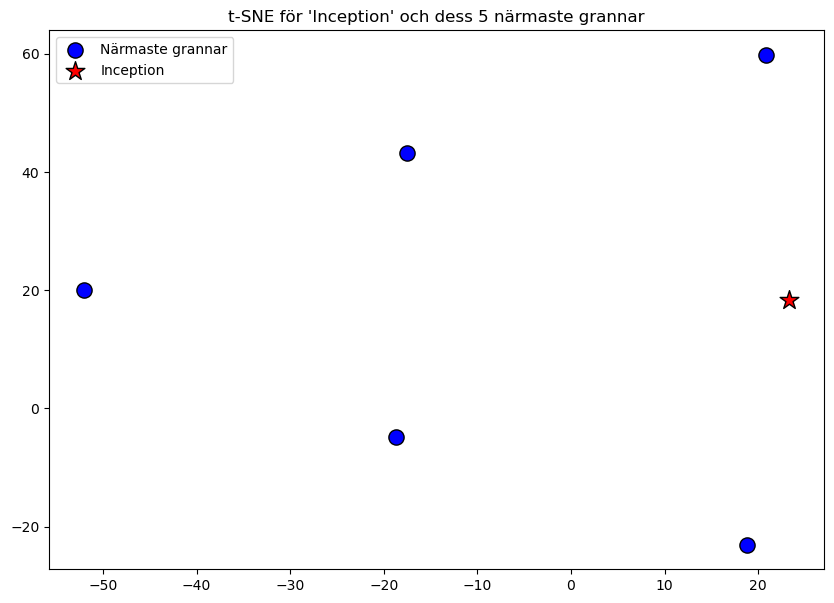


De 5 närmaste filmerna till 'Inception':
1. Across the Universe
2. Stranger than Fiction
3. Yes Man
4. Rize
5. The Lord of the Rings: The Return of the King

--- Klusterprofilering
Cluster 0:
   Vanligaste Type     = Children & Family Movies
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-PG
   Antal titlar        = 752

Cluster 1:
   Vanligaste Type     = Dramas, International Movies
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-MA
   Antal titlar        = 1174

Cluster 2:
   Vanligaste Type     = Documentaries
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-14
   Antal titlar        = 702

Cluster 3:
   Vanligaste Type     = Action & Adventure
   Vanligaste Category = Movie
   Vanligaste Rating   = R
   Antal titlar        = 998

Cluster 4:
   Vanligaste Type     = Dramas, International Movies
   Vanligaste Category = Movie
   Vanligaste Rating   = TV-14
   Antal titlar        = 1080

Cluster 5:
   Vanligaste Type     = Stand-Up Comedy
   Vanligast

In [10]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt

# Steg 1: Läs in data
df = pd.read_csv("Netflix Dataset.csv")

# Separera filmer (minuter) och serier (säsonger)
movies = df[df['Duration'].str.contains("min", na=False)].copy()
shows = df[df['Duration'].str.contains("Season", na=False)].copy()

# Extrahera minuter/säsonger
movies['Minutes'] = movies['Duration'].str.extract(r'(\d+)').astype(float)
shows['Seasons'] = shows['Duration'].str.extract(r'(\d+)').astype(float)

# Rensa Duration-text
movies['Duration'] = movies['Duration'].str.replace(r'\d+', '', regex=True).str.strip()
shows['Duration'] = shows['Duration'].str.replace(r'\d+', '', regex=True).str.strip()

print(f"Antal filmer: {movies.shape[0]}")
print(movies[['Title', 'Duration', 'Minutes']].head())
print(f"Antal serier: {shows.shape[0]}")
print(shows[['Title', 'Duration', 'Seasons']].head())

# Hantera saknad description
movies['Description'] = movies['Description'].fillna("")

# Extrahera år
movies['Release_Year'] = pd.to_datetime(movies['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)

# Steg 2: Generera features
# Text (Description)
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
tfidf_desc = tfidf.fit_transform(movies['Description'])

# Kategoriska features
cat_cols = ['Type', 'Category', 'Rating', 'Country']
encoder = OneHotEncoder(handle_unknown='ignore')
cat_feats = encoder.fit_transform(movies[cat_cols].fillna("Unknown"))

# Numeriska features
num_feats = movies[['Release_Year', 'Minutes']].fillna(0).values
scaler = StandardScaler()
num_feats_scaled = scaler.fit_transform(num_feats)

# Kombinera features med vikter
tfidf_w = 0.7
cat_w   = 1.2
num_w   = 0.5

X = hstack([
    tfidf_desc * tfidf_w,
    cat_feats * cat_w,
    num_feats_scaled * num_w
])

# CSR-format
X_csr = csr_matrix(X)

# Steg 3: Klustring
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_csr)
movies['Cluster'] = clusters

# Title → index mapping
title_to_idx = pd.Series(movies.index.values, index=movies['Title']).to_dict()

# Funktion: hitta liknande filmer (samma typ)
def get_similar_cluster_fallback(title, top_n=5):
    """Hitta top-n liknande filmer, med fallback om samma typ/kluster saknas."""
    if title not in title_to_idx:
        return [], []

    idx = title_to_idx[title]
    pos = movies.index.get_loc(idx)
    movie_type = movies.loc[idx, 'Type']

    # Försök samma kluster + typ
    cluster_id = movies.loc[idx, 'Cluster']
    candidates = movies[
        (movies['Cluster'] == cluster_id) &
        (movies['Type'] == movie_type) &
        (movies.index != idx)
    ].index.tolist()

    # Fallback: ta hela datasetet (exkl. själv)
    if len(candidates) < top_n:
        candidates = movies[movies.index != idx].index.tolist()

    candidate_positions = [movies.index.get_loc(i) for i in candidates]
    candidate_X = X_csr[candidate_positions]
    movie_vec = X_csr[pos]
    sims = cosine_similarity(movie_vec, candidate_X).flatten()
    top_positions = np.argsort(sims)[::-1][:top_n]
    similar_idx = [candidates[i] for i in top_positions]

    return movies.loc[similar_idx, 'Title'].tolist(), similar_idx

def plot_cluster_with_neighbors_fallback(title, top_n=5):
    titles, sim_idx = get_similar_cluster_fallback(title, top_n)
    if len(titles) == 0:
        print("Inga grannar hittades.")
        return

    idx = title_to_idx[title]
    pos = movies.index.get_loc(idx)
    sim_positions = [movies.index.get_loc(i) for i in sim_idx]

    # Subset för t-SNE
    subset_idx = [pos] + sim_positions
    X_subset = X_csr[subset_idx].toarray()

    # PCA → 50D max
    n_components = min(50, X_subset.shape[0], X_subset.shape[1])
    X_subset_50d = PCA(n_components=n_components, random_state=42).fit_transform(X_subset)

    # TSNE: perplexity < n_samples
    perplexity = min(5, len(subset_idx)-1)
    perplexity = max(1, perplexity)
    X_2d = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(X_subset_50d)

    plt.figure(figsize=(10, 7))
    plt.scatter(X_2d[1:,0], X_2d[1:,1], c="blue", s=120, label="Närmaste grannar", edgecolor="black")
    plt.scatter(X_2d[0,0], X_2d[0,1], c="red", s=200, label=title, edgecolor="black", marker="*")
    plt.title(f"t-SNE för '{title}' och dess {len(titles)} närmaste grannar")
    plt.legend()
    plt.show()

    print(f"\nDe {len(titles)} närmaste filmerna till '{title}':")
    for i, t in enumerate(titles, 1):
        print(f"{i}. {t}")


# Testa med Inception
plot_cluster_with_neighbors_fallback("Inception", top_n=5)

# Klusterprofilering
print("\n--- Klusterprofilering")
for cluster_id, group in movies.groupby("Cluster"):
    most_common_type = group['Type'].mode()[0] if not group['Type'].mode().empty else "Okänd"
    most_common_cat = group['Category'].mode()[0] if not group['Category'].mode().empty else "Okänd"
    most_common_rating = group['Rating'].mode()[0] if not group['Rating'].mode().empty else "Okänd"
    
    print(f"Cluster {cluster_id}:")
    print(f"   Vanligaste Type     = {most_common_type}")
    print(f"   Vanligaste Category = {most_common_cat}")
    print(f"   Vanligaste Rating   = {most_common_rating}")
    print(f"   Antal titlar        = {len(group)}\n")


In [1]:
import optuna
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import joblib

# Skapa syntetisk dataset
X, y = make_classification(
    n_samples=1000, 
    n_features=10, 
    n_informative=5, 
    n_redundant=2, 
    random_state=42
)

# Dela upp data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Definiera objektiv funktion för optimering
def objective(trial):
    
    # Föreslå hyperparametrar
    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # Skapa modell med föreslagna parametrar
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    # Använd korsvalidering för att evaluera modellen
    cv_scores = cross_val_score(clf, X_train, y_train, cv=3, scoring='accuracy')
    
    # Returnera negativ medel accuracy (eftersom Optuna minimerar)
    return -cv_scores.mean()

# Skapa en study och optimera
print("Startar hyperparameteroptimering med Optuna...")
study = optuna.create_study(
    direction='minimize',
    study_name='random_forest_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Kör optimeringen
study.optimize(objective, n_trials=50)

# Visa resultat
print(f"Antal trials: {len(study.trials)}")
print(f"Bästa värde: {study.best_value:.4f}")
print(f"Bästa parametrar: {study.best_params}")

[I 2025-09-15 14:41:27,901] A new study created in memory with name: random_forest_optimization


Startar hyperparameteroptimering med Optuna...


[I 2025-09-15 14:41:29,152] Trial 0 finished with value: -0.9162606891761239 and parameters: {'n_estimators': 44, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.9162606891761239.
[I 2025-09-15 14:41:31,581] Trial 1 finished with value: -0.9162606891761239 and parameters: {'n_estimators': 88, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.9162606891761239.
[I 2025-09-15 14:41:32,783] Trial 2 finished with value: -0.826241634047666 and parameters: {'n_estimators': 26, 'max_depth': 2, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: -0.9162606891761239.
[I 2025-09-15 14:41:33,269] Trial 3 finished with value: -0.8825058901936488 and parameters: {'n_estimators': 22, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.9162606891761239

Antal trials: 50
Bästa värde: -0.9288
Bästa parametrar: {'n_estimators': 30, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Ladda data
df = pd.read_csv("Netflix Dataset.csv")

# Kolla datatyper
print(df.dtypes)
print(df.head())

# Filmer: Duration innehåller "min"
movies = df[df['Duration'].str.contains("min", na=False)].copy()
shows = df[df['Duration'].str.contains("Season", na=False)].copy()

# Extrahera minuter och säsonger
movies['Minutes'] = movies['Duration'].str.extract(r'(\d+)').astype(float)
shows['Seasons'] = shows['Duration'].str.extract(r'(\d+)').astype(float)

# Rensa Duration-text
movies['Duration'] = movies['Duration'].str.replace(r'\d+', '', regex=True).str.strip()
shows['Duration'] = shows['Duration'].str.replace(r'\d+', '', regex=True).str.strip()

# Fyll missing description
movies['Description'] = movies['Description'].fillna("")
shows['Description'] = shows['Description'].fillna("")

# Extrahera år
movies['Release_Year'] = pd.to_datetime(movies['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)
shows['Release_Year'] = pd.to_datetime(shows['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)

# Kontrollera resultat
print(f"Antal filmer: {movies.shape[0]}")
print(movies[['Title', 'Duration', 'Minutes']].head())

print(f"Antal serier: {shows.shape[0]}")
print(shows[['Title', 'Duration', 'Seasons']].head())

# Splitta 'Type' till listor (anta att detta är genrer)
movies['Genres'] = movies['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])
shows['Genres'] = shows['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])

# Multi-hot encoding av genrer
mlb = MultiLabelBinarizer()
genres_movies = mlb.fit_transform(movies['Genres'])
genres_shows = mlb.transform(shows['Genres'])

# Vanliga kategoriska features
cat_cols = ['Category', 'Country', 'Rating']
encoder = OneHotEncoder(handle_unknown='ignore')

cat_movies = encoder.fit_transform(movies[cat_cols].fillna('Unknown'))
cat_shows = encoder.transform(shows[cat_cols].fillna('Unknown'))


class OptimizedRecommendationSystem:
    def __init__(self):
        self.tfidf_vectorizer = None
        self.scaler_movies = StandardScaler()
        self.scaler_shows = StandardScaler()
        self.kmeans_movies = None
        self.kmeans_shows = None
        self.X_movies = None
        self.X_shows = None
        self.title_to_idx_movies = None
        self.title_to_idx_shows = None
        self.best_params = None
        
    def build_features(self, movies_df, shows_df, tfidf_params):
        """Bygg features med optimerade parametrar"""
        # TF-IDF med optimerade parametrar
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=tfidf_params['max_features'],
            ngram_range=(1, tfidf_params['ngram_range']),
            min_df=tfidf_params['min_df'],
            max_df=tfidf_params['max_df'],
            stop_words='english'
        )
        
        tfidf_movies = self.tfidf_vectorizer.fit_transform(movies_df['Description'])
        tfidf_shows = self.tfidf_vectorizer.transform(shows_df['Description'])
        
        # Numeriska features
        num_movies = self.scaler_movies.fit_transform(movies_df[['Minutes', 'Release_Year']].fillna(0))
        num_shows = self.scaler_shows.fit_transform(shows_df[['Seasons', 'Release_Year']].fillna(0))
        
        # Kombinera alla features
        self.X_movies = hstack([tfidf_movies, cat_movies, genres_movies, num_movies])
        self.X_shows = hstack([tfidf_shows, cat_shows, genres_shows, num_shows])
        
        self.X_movies = csr_matrix(self.X_movies)
        self.X_shows = csr_matrix(self.X_shows)
        
        return self.X_movies, self.X_shows
    
    def cluster_content(self, cluster_params):
        """Utför klustring med optimerade parametrar"""
        self.kmeans_movies = KMeans(
            n_clusters=cluster_params['n_clusters_movies'],
            random_state=42,
            n_init=10
        )
        movies['Cluster'] = self.kmeans_movies.fit_predict(self.X_movies)
        
        self.kmeans_shows = KMeans(
            n_clusters=cluster_params['n_clusters_shows'],
            random_state=42,
            n_init=10
        )
        shows['Cluster'] = self.kmeans_shows.fit_predict(self.X_shows)
        
        # Skapa title mappings
        self.title_to_idx_movies = pd.Series(movies.index.values, index=movies['Title']).to_dict()
        self.title_to_idx_shows = pd.Series(shows.index.values, index=shows['Title']).to_dict()
        
        # Beräkna silhouette score för utvärdering
        sil_movies = silhouette_score(self.X_movies, movies['Cluster'])
        sil_shows = silhouette_score(self.X_shows, shows['Cluster'])
        
        return (sil_movies + sil_shows) / 2
    
    def get_similar(self, title, top_n=5, is_movie=True, similarity_threshold=0.1):
        """Hitta liknande innehåll med förbättrad algoritm"""
        if is_movie:
            df_ = movies
            X_ = self.X_movies
            title_to_idx = self.title_to_idx_movies
        else:
            df_ = shows
            X_ = self.X_shows
            title_to_idx = self.title_to_idx_shows
            
        if title not in title_to_idx:
            return [], []
        
        idx = title_to_idx[title]
        pos = df_.index.get_loc(idx)
        cluster_id = df_.loc[idx, 'Cluster']
        
        # Kandidater i samma kluster först
        same_cluster = df_[(df_['Cluster'] == cluster_id) & (df_.index != idx)].index.tolist()
        
        if len(same_cluster) >= top_n:
            candidates = same_cluster
        else:
            # Lägg till från andra kluster om nödvändigt
            other_cluster = df_[(df_['Cluster'] != cluster_id) & (df_.index != idx)].index.tolist()
            candidates = same_cluster + other_cluster
        
        if not candidates:
            return [], []
        
        candidate_pos = [df_.index.get_loc(i) for i in candidates]
        sims = cosine_similarity(X_[pos], X_[candidate_pos]).flatten()
        
        # Filtrera på similarity threshold
        valid_idx = np.where(sims >= similarity_threshold)[0]
        if len(valid_idx) == 0:
            valid_idx = np.arange(len(sims))  # Fallback
        
        top_idx = valid_idx[np.argsort(sims[valid_idx])[::-1][:top_n]]
        similar_idx = [candidates[i] for i in top_idx]
        
        return df_.loc[similar_idx, 'Title'].tolist(), similar_idx


def objective(trial):
    """Optuna objective function för hyperparameter optimering"""
    
    # Föreslå hyperparametrar
    tfidf_params = {
        'max_features': trial.suggest_int('max_features', 1000, 10000),
        'ngram_range': trial.suggest_int('ngram_range', 1, 3),
        'min_df': trial.suggest_float('min_df', 0.01, 0.1),
        'max_df': trial.suggest_float('max_df', 0.7, 0.95)
    }
    
    cluster_params = {
        'n_clusters_movies': trial.suggest_int('n_clusters_movies', 3, 15),
        'n_clusters_shows': trial.suggest_int('n_clusters_shows', 3, 10)
    }
    
    try:
        # Skapa och träna systemet
        rec_system = OptimizedRecommendationSystem()
        rec_system.build_features(movies, shows, tfidf_params)
        silhouette_avg = rec_system.cluster_content(cluster_params)
        
        # Testa rekommendationer på några exempel
        test_titles_movies = movies['Title'].head(10).tolist()
        test_titles_shows = shows['Title'].head(5).tolist()
        
        recommendation_quality = 0
        total_tests = 0
        
        # Testa filmrekommendationer
        for title in test_titles_movies:
            similar_titles, _ = rec_system.get_similar(title, top_n=5, is_movie=True)
            if similar_titles:
                recommendation_quality += len(similar_titles) / 5.0
            total_tests += 1
        
        # Testa serierekommendationer
        for title in test_titles_shows:
            similar_titles, _ = rec_system.get_similar(title, top_n=5, is_movie=False)
            if similar_titles:
                recommendation_quality += len(similar_titles) / 5.0
            total_tests += 1
        
        if total_tests > 0:
            recommendation_quality /= total_tests
        
        # Kombinera silhouette score och recommendation quality
        final_score = 0.6 * silhouette_avg + 0.4 * recommendation_quality
        
        return final_score
        
    except Exception as e:
        print(f"Fel i trial: {e}")
        return -1.0


def run_optimization():
    """Kör Optuna optimering"""
    print("Startar Optuna optimering...")
    
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    
    print("Optimering klar!")
    print(f"Bästa score: {study.best_value:.4f}")
    print(f"Bästa parametrar: {study.best_params}")
    
    return study.best_params, study


def plot_optimization_history(study):
    """Visualisera optimeringshistoriken"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Optimization history
    trials = study.trials
    values = [trial.value for trial in trials if trial.value is not None]
    
    ax1.plot(values, 'b-', alpha=0.7)
    ax1.set_title('Optimization History')
    ax1.set_xlabel('Trial')
    ax1.set_ylabel('Objective Value')
    ax1.grid(True)
    
    # Parameter importance
    try:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())
        importances = list(importance.values())
        
        ax2.barh(params, importances)
        ax2.set_title('Parameter Importance')
        ax2.set_xlabel('Importance')
    except:
        ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                ha='center', va='center', transform=ax2.transAxes)
    
    plt.tight_layout()
    plt.show()


def create_optimized_system(best_params):
    """Skapa det optimerade systemet med bästa parametrarna"""
    print("Skapar optimerat rekommendationssystem...")
    
    rec_system = OptimizedRecommendationSystem()
    
    tfidf_params = {
        'max_features': best_params['max_features'],
        'ngram_range': best_params['ngram_range'],
        'min_df': best_params['min_df'],
        'max_df': best_params['max_df']
    }
    
    cluster_params = {
        'n_clusters_movies': best_params['n_clusters_movies'],
        'n_clusters_shows': best_params['n_clusters_shows']
    }
    
    rec_system.build_features(movies, shows, tfidf_params)
    silhouette_score = rec_system.cluster_content(cluster_params)
    
    print(f"Silhouette Score: {silhouette_score:.4f}")
    print("System är redo!")
    
    return rec_system


def plot_tsne_optimized(rec_system, title, top_n=5, is_movie=True):
    """t-SNE visualisering med det optimerade systemet"""
    if is_movie:
        df_ = movies
        X_ = rec_system.X_movies
        title_to_idx = rec_system.title_to_idx_movies
    else:
        df_ = shows
        X_ = rec_system.X_shows
        title_to_idx = rec_system.title_to_idx_shows
    
    titles, sim_idx = rec_system.get_similar(title, top_n, is_movie)
    if len(titles) == 0:
        print(f"Titel '{title}' hittades inte.")
        return
    
    idx = title_to_idx[title]
    pos = df_.index.get_loc(idx)
    sim_positions = [df_.index.get_loc(i) for i in sim_idx]
    
    # PCA → 50D först för att minska dimensionalitet
    n_components = min(50, X_.shape[1], X_.shape[0]-1)
    X_50d = PCA(n_components=n_components, random_state=42).fit_transform(X_.toarray())
    
    # t-SNE → 2D
    perplexity = min(30, len(df_)-1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca')
    X_2d = tsne.fit_transform(X_50d)
    
    plt.figure(figsize=(12, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', alpha=0.3, label='Alla', s=20)
    plt.scatter(X_2d[sim_positions, 0], X_2d[sim_positions, 1], 
               c='blue', s=120, label='Rekommendationer', edgecolor='black', alpha=0.8)
    plt.scatter(X_2d[pos, 0], X_2d[pos, 1], 
               c='red', s=200, label=title, marker='*', edgecolor='black')
    
    plt.title(f"t-SNE Klustervisualisering (Optimerad) för '{title}'")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\nDe {len(titles)} bästa rekommendationerna för '{title}':")
    for i, t in enumerate(titles, 1):
        print(f"{i}. {t}")


# Huvudkörning
if __name__ == "__main__":
    # Kör optimering
    best_params, study = run_optimization()
    
    # Visualisera optimering
    plot_optimization_history(study)
    
    # Skapa optimerat system
    optimized_system = create_optimized_system(best_params)
    
    # Testa systemet
    if len(movies) > 0:
        test_movie = movies['Title'].iloc[0]
        print(f"\nTestar med film: {test_movie}")
        plot_tsne_optimized(optimized_system, test_movie, top_n=5, is_movie=True)
    
    if len(shows) > 0:
        test_show = shows['Title'].iloc[0]
        print(f"\nTestar med serie: {test_show}")
        plot_tsne_optimized(optimized_system, test_show, top_n=5, is_movie=False)